In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import nest_asyncio
nest_asyncio.apply()

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "vscode"            

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import matplotlib.dates as mdates
plt.style.use('ggplot')
params = {'legend.fontsize': 'medium',
        'figure.figsize': (20, 12),
        'axes.labelsize': 'medium',
        'axes.titlesize':'medium',
        'xtick.labelsize':'medium',
        'ytick.labelsize':'medium'}
pylab.rcParams.update(params)

import pandas as pd
import numpy as np
import rateslib as rl
import QuantLib as ql

import time
import datetime
import pytz

NY_tz = pytz.timezone("America/New_York") 
CHI_tz = pytz.timezone("America/Chicago") 
LDN_tz = pytz.timezone("Europe/London") 
UTC_tz = pytz.timezone("UTC") 

import sys
sys.path.append("../")

from RVUtils.plt_timeseries import make_secondary_axis_plot

In [16]:
# from Caching.curve_store import CurveStore
# store = CurveStore()
# df = store.read_raw_day("USD-SOFR-1D-Q12STIRT", datetime.date(2026, 3, 10))
# print(f"{len(df)} snapshots, time range: {df['timestamp_utc'].min()} → {df['timestamp_utc'].max()}")

In [2]:
from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP
from TB.IRSwapsTB import IRSwapsTB
from Query.IRSwaps.IRSwapQuery import IRSwapQuery, IRSwapStructure, IRSwapValue

from MDP.FixedRateBonds.FixedRateBondsMDP import FixedRateBondsMDP, _alias_to_cusip
from TB.FixedRateBondsTB import FixedRateBondsTB

from MDP.STIRFutures.STIRFutureMDP import STIRFutureMDP
from MDP.IRSwaps.BARCHART_STIRF.rl import plot_overnight_forward_curves

from BT.misc import ql_cal_date_range

In [18]:
# curve_mdp = IRSwapsMDP(source="BARCHART_STIRF-RL")
# curve_mdp.get_pricer(
#     request=dict(
#         curve_name="USD-SOFR-1D-Q12STIRT",
#         timestamp=CHI_tz.localize(datetime.datetime(2026, 3, 13, 12, 14)),
#         # force_refresh=True, 
# 		# cache_full_intraday_fetch=True,
#     )
# )

In [3]:
from Query.Unified.UnifiedQuery import UnifiedQuery
from Query.Unified.registry import UnifiedStructure, UnifiedValue
from TB.TimeseriesBuilder import TimeseriesBuilder

NYC = pytz.timezone("America/New_York")

# curve_mdp = IRSwapsMDP(source="BARCHART_STIRF-RL")
curve_mdp = IRSwapsMDP(source="ERIS_EOD_LIVE-RL_BASIC")
# curve_mdp = IRSwapsMDP(source="ERIS_EOD_LIVE-RL_BASIC-NOJUMPS")

# usts_mdp = FixedRateBondsMDP(source="USTS_WEBULL_WSJ_LIVE-RL")
usts_mdp = FixedRateBondsMDP(source="USTS_FEDINVEST_WSJ_LIVE-RL")

ts_builder = TimeseriesBuilder()

In [ ]:
start = NYC.localize(datetime.datetime(2022, 11, 20, 17, 00))
end = NYC.localize(datetime.datetime(2026, 3, 23, 17, 00))

df = ts_builder.get_timeseries(
    start=start,
    end=end,
    queries=[
        UnifiedQuery(
			curve="USD-SOFR-1D",
			tenor="CT7/CT20",
			# value=UnifiedValue.IRS_SPREADOVER,
			value=UnifiedValue.IRS_MMSS,
		),
		UnifiedQuery(
			curve="USD-SOFR-1D",
			tenor="CT7/CT20",
			value=UnifiedValue.IRS_SPREADOVER,
		)
		# UnifiedQuery(
		# 	cusip="CT10",
		# 	value=UnifiedValue.FRB_YTM,
		# )
	],
    n_jobs=12,
	  routers={
        "IRS": IRSwapsTB(curve_mdp, show_tqdm=True),
        "FRB": FixedRateBondsTB(usts_mdp, show_tqdm=True),
    },
)
df

PRICING USD-SOFR-1D IRSWAPS [workers=12]...: 100%|██████████| 2/2 [00:00<00:00, 18.36it/s]


,USD-SOFR-1D CT7/CT20 CURVE MMSS,USD-SOFR-1D CT7/CT20 CURVE SPREADOVER
Date,,
2022-11-21,-40.215824,-40.384374
2022-11-22,-40.269077,-40.367665
2022-11-23,-39.024229,-39.101326
2022-11-25,-40.929138,-40.993741
2022-11-28,-39.231299,-39.316170
...,...,...
2026-03-17,-35.225616,-35.469973
2026-03-18,-35.154339,-35.370338
2026-03-19,-38.563722,-38.752054


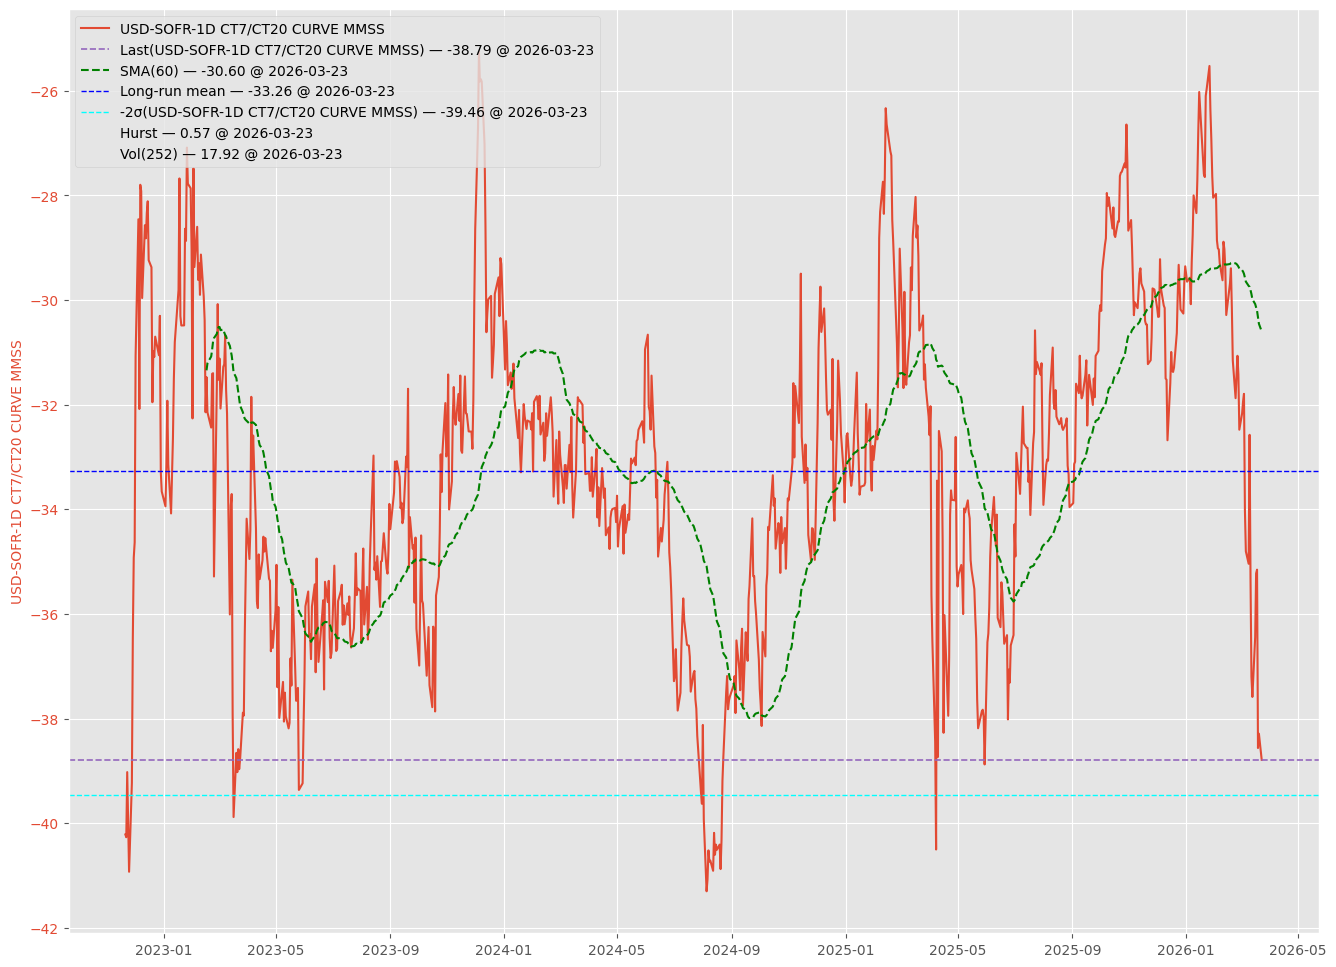

In [ ]:
# plot, fig, ax, ax2, legend = make_secondary_axis_plot(engine="plotly")
plot, fig, ax, ax2, legend = make_secondary_axis_plot()

plot(
    df["USD-SOFR-1D CT7/CT20 CURVE MMSS"],
    which="left",
    indicators=[
        {"kind": "last", "style": {"linestyle": "--", "linewidth": 1.2, "color": "tab:purple"}},  
        {"kind": "sma", "window": 60, "style": {"linestyle": "--", "color": "green"}},
        {"kind": "simple_avg", "label": "Long-run mean", "style": {"linestyle": "--", "color": "blue"}},
		{"kind": "hurst", "hide": True},
		{"kind": "vol", "returns": "normal", "window": 252, "hide": True},
		{
            "kind": "full_sigma",
            "n": 2,
            "hide_center": True,
            "hide_upper": True,
            "hide_lower": False,
            "style_upper": {"linestyle": "--", "color": "cyan"},
            "style_lower": {"linestyle": "--", "color": "cyan"},
        },
    ],
    # ou={"enable": True, "steps": 126, "add_metrics_to_legend": True}
)
# plot(df["USD-SOFR-1D 10y/30y CURVE RATE"], which="left")
# plot(df["USD-SOFR-1D 30y OUTRIGHT RATE"], which="right")
legend(show_date=True, loc="upper left")
plt.show()

In [5]:
curve = "USD-SOFR-1D"
curve_handle = curve_mdp._get_curve(curve_name=curve, timestamp="live")

risk = 100_000
outright_query = IRSwapQuery(curve=curve, tenor="IMM_Z29xIMM_H30", structure_kwargs={"bpv": risk}).resolve_query(
    "live", pricer_or_curve=curve_handle
)
outright_pkg, outright_rws = outright_query.resolve_package(pricer_or_curve=curve_handle)

outright_vmap = outright_query.build_value_map(pricer_or_curve=curve_handle, package=outright_pkg, risk_weights=outright_rws)
for v in [IRSwapValue.RATE, IRSwapValue.NPV, IRSwapValue.NOTIONAL, IRSwapValue.PV01]:
    print(v.name, outright_vmap.apply(value=v))

print(curve_handle.effective_date(outright_pkg[0]))
print(curve_handle.maturity_date(outright_pkg[0]))

AssertionError: live is a holiday in the US government bond market calendar!

In [ ]:
from MDP.STIRConvexityAdjustment.STIRConvexityAdjustmentMDP import STIRConvexityAdjustmentMDP
from Query.Spreads.SpreadQuery import SpreadQuery
from Query.Spreads.SpreadValue import SpreadValue

mdp = STIRConvexityAdjustmentMDP(source_a="BARCHART_STIRF-RL", source_b="ERIS_EOD_LIVE-RL_BASIC-NOJUMPS")

eod = NY_tz.localize(datetime.datetime(2026, 3, 10, 17, 00))

q = IRSwapQuery(
    tenor="IMM_H29xIMM_Z29",
    value=IRSwapValue.CVX_ADJ_EMPIRICAL,
    market_request={
        "curve_name_a": "USD-SOFR-1D-Q16STIRT",
        "curve_name_b": "USD-SOFR-1D",
    },
)

request = q.build_mdp_request(eod)
pricer = mdp.get_pricer(request)
package, weights = q.resolve_package(pricer_or_curve=pricer)
# val_map = q.build_value_map(pricer_or_curve=pricer, package=package, risk_weights=weights)
val_map = q.build_value_map(pricer_or_curve=pricer, **dict(zip(("package", "risk_weights"), q.resolve_package(pricer_or_curve=pricer))))
cvx_adj_bps = float(val_map.apply(IRSwapValue.CVX_ADJ_EMPIRICAL))
print(cvx_adj_bps)

6.28942097885013


In [ ]:
pricer.__dict__

{'pricer_a': RLIRSwapCurve(_rl_curve_id='USD-SOFR-1D', _rl_curve_handle=<rl.Curve:USD-SOFR-1D at 0x17d611c2f90>, _meta_data={'timestamp': datetime.datetime(2026, 3, 13, 17, 0, tzinfo=<DstTzInfo 'America/New_York' EDT-1 day, 20:00:00 DST>), 'id': 'BARCHART_STIRF-RL-USD-SOFR-1D-Q16STIRT-2026-03-13 17:00:00-04:00', 'requested_curve_name': 'USD-SOFR-1D-Q16STIRT', 'curve_name': 'USD-SOFR-1D-Q16STIRT'}),
 'pricer_b': RLIRSwapCurve(_rl_curve_id='USD-SOFR-1D', _rl_curve_handle=<rl.Curve:ERIS_EOD_LIVE-RL_BASIC-NOJUMPS-USD-SOFR-1D-2026-03-13_nojumps-2026-03-13 15:00:00-04:00 at 0x17d611ca490>, _meta_data={'timestamp': datetime.datetime(2026, 3, 13, 15, 0, tzinfo=<DstTzInfo 'America/New_York' EDT-1 day, 20:00:00 DST>), 'id': 'ERIS_EOD_LIVE-RL_BASIC-NOJUMPS-USD-SOFR-1D-2026-03-13'}),
 '_meta_data': {'source': 'STIRCVX_EMPIRICAL',
  'request': {'curve_name_a': 'USD-SOFR-1D-Q16STIRT',
   'curve_name_b': 'USD-SOFR-1D',
   'timestamp': datetime.datetime(2026, 3, 13, 17, 0, tzinfo=<DstTzInfo 'America/N

# New MDPs

In [ ]:
from MDP.IRClearingHouseBasisSwaps.IRClearingHouseBasisSwapsMDP import IRClearingHouseBasisSwapsMDP
from Query.Spreads.SpreadQuery import SpreadQuery, SpreadValue

mdp = IRClearingHouseBasisSwapsMDP()
pricer = mdp.get_pricer({
    "tenor": "10Y",
    "index": "SOFR",
    "start_date": datetime.date(2026, 1, 1),
    "end_date": datetime.date(2026, 2, 20),
})
pricer

In [ ]:
from MDP.EventContracts.EventContractsMDP import EventContractsMDP
from Query.EventContracts.EventContractQuery import EventContractQuery
from Query.EventContracts.EventContractValue import EventContractValue
from Query.EventContracts.EventContractStructure import EventContractStructure

# ── Step 1: Fetch the Pricer ──────────────────────────────────────────
mdp = EventContractsMDP(source="KALSHI")
pricer = mdp.get_pricer(
    {
        "ticker": "KXRATECUTCOUNT-26DEC31-T3",
        "timestamp": "live",
    }
)

# ── Step 2: Build the Query ──────────────────────────────────────────
q = EventContractQuery(
    structure=EventContractStructure.OUTRIGHT,
    value=EventContractValue.PRICE,
    ticker="KXRATECUTCOUNT-26DEC31-T3",
)

# ── Step 3: Resolve the Package ──────────────────────────────────────
package, risk_weights = q.resolve_package(pricer_or_curve=pricer)

# ── Step 4: Build the Value Map ──────────────────────────────────────
value_map = q.build_value_map(
    pricer_or_curve=pricer,
    package=package,
    risk_weights=risk_weights,
)

# ── Step 5: Evaluate ─────────────────────────────────────────────────
price = value_map.apply(EventContractValue.PRICE)
prob = value_map.apply(EventContractValue.PROBABILITY)
volume = value_map.apply(EventContractValue.VOLUME)
oi = value_map.apply(EventContractValue.OPEN_INTEREST)

print(f"Price:       {price}")
print(f"Probability: {prob}")
print(f"Volume:      {volume}")
print(f"OI:          {oi}")


quantity = 100_000

avg_price = value_map.apply(
    EventContractValue.MARKET_IMPACT_AVG_PRICE,
    quantity=quantity,
    side="yes",
)
slippage = value_map.apply(
    EventContractValue.MARKET_IMPACT_SLIPPAGE,
    quantity=quantity,
    side="yes",
)
total_cost = value_map.apply(
    EventContractValue.MARKET_IMPACT_TOTAL_COST,
    quantity=quantity,
    side="yes",
)

print(f"\n── Market Impact (buy 500 YES) ──")
print(f"Avg Fill:    {avg_price}")
print(f"Slippage:    {slippage}")
print(f"Total Cost:  ${total_cost:.2f}")

Price:       0.13
Probability: 0.13
Volume:      610.0
OI:          116894.0

── Market Impact (buy 500 YES) ──
Avg Fill:    0.22278129999999993
Slippage:    0.09278129999999993
Total Cost:  $22278.13


In [ ]:
book = pricer.get_orderbook()

In [ ]:
book

{'yes':    price  quantity
 0   0.02    1309.0
 1   0.05    2000.0
 2   0.09    2060.0
 3   0.10     100.0
 4   0.11    8817.0
 5   0.12    2472.0,
 'no':     price  quantity
 0    0.01    4650.0
 1    0.02    2900.0
 2    0.03    1000.0
 3    0.25      39.0
 4    0.26      37.0
 ..    ...       ...
 61   0.83      20.0
 62   0.84    3060.0
 63   0.85    2000.0
 64   0.86     200.0
 65   0.87    2322.0
 
 [66 rows x 2 columns]}

In [ ]:
mdp = EventContractsMDP(source="POLYMARKET")
pricer = mdp.get_pricer({
    "token_id": "113379839734351069617987084078322474966003108854908079701423911002443710490196",
})
pricer.latest_price()

0.305